# Content generation: simple evals

Imagine your marketing team is preparing for a new product launch and needs to publish updates on social media every day. Writing short, catchy tweets takes time, so you decide to use an LLM to generate first drafts automatically. However, not every model output is ready to post. Some tweets are too long, some include emojis that do not match the brand style, and others forget to add important hashtags.

To make this workflow reliable, you start with a few simple automated checks: the tweet must stay within the character limit, avoid emojis, and include at least one hashtag.

In this example, we will build and test these lightweight rules, use them to find one visible failure mode in a slice of generated content, and then look at a counterexample that passes all checks but is still not good enough.


In [1]:
# Import libraries
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
pd.set_option('display.max_colwidth', None)

## 1. Synthetic Dataset

We will create a static dataset with topics and generated tweets. Most topics pass the checks, but one slice is intentionally problematic: webinar announcements are consistently too long.

There is also one deliberately bad output hidden inside the dataset. It satisfies the simple rules, but it is not a useful marketing tweet. We will come back to it after the aggregate evaluation.


In [3]:
# Static synthetic dataset

synthetic_data = [
    # Product launch
    ("Product launch", "Introducing InsightPulse: real-time monitoring for ML models in production. Catch drift early and debug faster. #MLOps #AI"),
    ("Product launch", "Our new eval templates help teams test LLM apps before release, starting with simple checks. #LLM #Evals"),
    ("Product launch", "New build is live: clearer reports, faster eval runs, and saved filters for prompt reviews. #ProductUpdate #LLM"),
    ("Product launch", "Ship with more confidence: generate, validate, retry, and track failures in one workflow. #Automation #Quality"),
    ("Product launch", "Today we added release notes for eval changes so teams can review model behavior over time. #AI #Product"),
    ("Product launch", "Buy now. #AI"),

    # Webinar announcement
    ("Webinar announcement", "Join our live webinar on practical LLM evaluation with Maya Chen, Senior AI Engineer, on October 12 at 10:00 UTC. We will cover length checks, tone constraints, hashtag rules, failure reports, and a step-by-step workflow your team can reuse after the session, plus a short Q&A on adapting this to real launch campaigns. #LLM #Evaluation #Webinar"),
    ("Webinar announcement", "Register for our webinar with product lead Sam Rivera on October 14 at 16:00 UTC. Learn how to design lightweight evals, review failing outputs, and improve prompts. #LLM #Evals #Webinar"),
    ("Webinar announcement", "Tomorrow's webinar brings together an engineer, a PM, and a developer advocate to walk through a tweet-generation example, show the validation code, discuss common failure patterns, and answer questions from teams shipping AI features across regulated, brand-sensitive, and high-volume workflows. #AI #Quality #Webinar"),
    ("Webinar announcement", "Save your seat for a live workshop on LLM output validation. We will demo the dataset, inspect failures, and share a reusable checklist. #LLM #Testing #Webinar"),
    ("Webinar announcement", "In next week's session, our team will show how to evaluate generated marketing copy across length, formatting, and brand constraints, then use the results to revise prompts for webinar posts, launch posts, and hiring updates, with a concrete before-and-after prompt rewrite. #MarketingAI #Evals #Webinar"),

    # Hiring
    ("Hiring", "We are hiring a Product Designer who loves turning complex systems into simple experiences. #Hiring #Design"),
    ("Hiring", "We are hiring a Backend Engineer to scale evaluation pipelines for fast-moving AI teams. #Hiring #Engineering"),
    ("Hiring", "Join our team to build tools that make AI products easier to test, debug, and ship. #Hiring #AI"),
    ("Hiring", "Open role: Developer Advocate for practical LLM evaluation examples, docs, and demos. #Hiring #DevRel"),
    ("Hiring", "We are growing our infrastructure team to support faster eval runs and clearer reports. #Hiring #Infrastructure"),

    # Feature update
    ("Feature update", "New dashboard view: compare prompt variants side by side and track quality over time. #ProductUpdate #Evals"),
    ("Feature update", "You can now group evaluation results by scenario and filter by failure type. #ProductUpdate #LLM"),
    ("Feature update", "Saved filters make recurring checks faster for teams reviewing prompt changes each week. #Evals #Product"),
    ("Feature update", "New export flow: share concise eval summaries with reviewers before a release. #Quality #AI"),
    ("Feature update", "We added clearer failure labels so teams can see which constraints broke most often. #Testing #ProductUpdate"),

    # Conference promo
    ("Conference promo", "See you at PyData London. We will demo lightweight tests for multi-step AI workflows. #PyData #AI"),
    ("Conference promo", "Catch our talk next week on LLM workflow evaluation, from constraints to failure reports. #Conference #LLM"),
    ("Conference promo", "Visit our booth for a hands-on look at eval templates for generated content. #Conference #Evals"),
    ("Conference promo", "We are sharing a practical checklist for debugging LLM outputs at the conference. #AI #Quality"),
    ("Conference promo", "Our session covers simple checks, slice analysis, and prompt iteration for AI products. #LLM #Conference"),
]

# Convert to pandas DataFrame
df = pd.DataFrame(synthetic_data, columns=["topic", "tweet"])

df["char_count"] = df["tweet"].str.len()

print(f"Total tweets in the dataset: {len(df)}")
df.head()


Total tweets in the dataset: 26


,topic,tweet,char_count
0,Product launch,Introducing InsightPulse: real-time monitoring for ML models in production. Catch drift early and debug faster. #MLOps #AI,122
1,Product launch,"Our new eval templates help teams test LLM apps before release, starting with simple checks. #LLM #Evals",104
2,Product launch,"New build is live: clearer reports, faster eval runs, and saved filters for prompt reviews. #ProductUpdate #LLM",111
3,Product launch,"Ship with more confidence: generate, validate, retry, and track failures in one workflow. #Automation #Quality",110
4,Product launch,Today we added release notes for eval changes so teams can review model behavior over time. #AI #Product,104


## 2. Validation Checks

We will implement validation checks using raw Python and regular expressions.


In [4]:
# Set tweet length limit and compile regex patterns once for efficiency
len_limit = 280

# A compact, dependency-free emoji detector.
# These ranges cover the main Unicode emoji blocks, including newer pictographs.
EMOJI_RANGES = [
    ("🇦", "🇿"),  # flags
    ("🌀", "🗿"),  # symbols and pictographs
    ("😀", "🙏"),  # emoticons
    ("🚀", "🛿"),  # transport and map symbols
    ("🤀", "🧿"),  # supplemental symbols and pictographs
    ("🩰", "🫿"),  # symbols and pictographs extended-A
    ("☀", "➿"),          # miscellaneous symbols and dingbats
]


def contains_emoji(text):
    return any(
        start <= char <= end
        for char in text
        for start, end in EMOJI_RANGES
    )


hashtag_pattern = re.compile(r"#\w+")


In [5]:
# Apply validation to all tweets in the dataset
df["length_ok"] = df["tweet"].apply(lambda x: len(x) <= len_limit)
df["no_emoji"] = df["tweet"].apply(lambda x: not contains_emoji(x))
df["has_hashtag"] = df["tweet"].apply(lambda x: bool(hashtag_pattern.search(x)))

df.head()


,topic,tweet,char_count,length_ok,no_emoji,has_hashtag
0,Product launch,Introducing InsightPulse: real-time monitoring for ML models in production. Catch drift early and debug faster. #MLOps #AI,122,True,True,True
1,Product launch,"Our new eval templates help teams test LLM apps before release, starting with simple checks. #LLM #Evals",104,True,True,True
2,Product launch,"New build is live: clearer reports, faster eval runs, and saved filters for prompt reviews. #ProductUpdate #LLM",111,True,True,True
3,Product launch,"Ship with more confidence: generate, validate, retry, and track failures in one workflow. #Automation #Quality",110,True,True,True
4,Product launch,Today we added release notes for eval changes so teams can review model behavior over time. #AI #Product,104,True,True,True


In [6]:
# Add tests summary across tweets
df["passed_all"] = df["length_ok"] & df["no_emoji"] & df["has_hashtag"]
df["score"] = df[["length_ok", "no_emoji", "has_hashtag"]].sum(axis=1)

df.head()

,topic,tweet,char_count,length_ok,no_emoji,has_hashtag,passed_all,score
0,Product launch,Introducing InsightPulse: real-time monitoring for ML models in production. Catch drift early and debug faster. #MLOps #AI,122,True,True,True,True,3
1,Product launch,"Our new eval templates help teams test LLM apps before release, starting with simple checks. #LLM #Evals",104,True,True,True,True,3
2,Product launch,"New build is live: clearer reports, faster eval runs, and saved filters for prompt reviews. #ProductUpdate #LLM",111,True,True,True,True,3
3,Product launch,"Ship with more confidence: generate, validate, retry, and track failures in one workflow. #Automation #Quality",110,True,True,True,True,3
4,Product launch,Today we added release notes for eval changes so teams can review model behavior over time. #AI #Product,104,True,True,True,True,3


## 3. Statistics Over Evaluated Metrics

Calculate and display statistics for each validation metric. The goal is not only to count failures, but also to find whether failures cluster in a specific slice.


In [7]:
# Checks summary
report = df.groupby("topic").agg(
    total_tweets=("tweet", "count"),
    passed=("passed_all", "sum"),
    failed=("passed_all", lambda x: (~x).sum()),
    pass_rate=("passed_all", "mean"),
    avg_chars=("char_count", "mean"),
)

report["pass_rate"] = (report["pass_rate"] * 100).round(1)
report["avg_chars"] = report["avg_chars"].round(1)

report


,total_tweets,passed,failed,pass_rate,avg_chars
topic,,,,,
Conference promo,5,5,0,100.0,99.2
Feature update,5,5,0,100.0,101.2
Hiring,5,5,0,100.0,104.6
Product launch,6,6,0,100.0,93.8
Webinar announcement,5,2,3,40.0,262.2


In [8]:
# Checks detailed summary
rows = []
test_cols = ["length_ok", "no_emoji", "has_hashtag"]

for topic, group in df.groupby("topic"):
    for test in test_cols:
        passed = group[test].sum()
        total = len(group)
        failed = total - passed

        rows.append({
            "topic": topic,
            "test": test,
            "passed": passed,
            "failed": failed,
            "pass_rate_%": round(passed / total * 100, 1)
        })

detailed_report = pd.DataFrame(rows)

detailed_report


,topic,test,passed,failed,pass_rate_%
0,Conference promo,length_ok,5,0,100.0
1,Conference promo,no_emoji,5,0,100.0
2,Conference promo,has_hashtag,5,0,100.0
3,Feature update,length_ok,5,0,100.0
4,Feature update,no_emoji,5,0,100.0
5,Feature update,has_hashtag,5,0,100.0
6,Hiring,length_ok,5,0,100.0
7,Hiring,no_emoji,5,0,100.0
8,Hiring,has_hashtag,5,0,100.0
9,Product launch,length_ok,6,0,100.0


In [9]:
pivot_report = detailed_report.pivot(
    index="topic",
    columns="test",
    values="pass_rate_%"
)

pivot_report

test,has_hashtag,length_ok,no_emoji
topic,,,
Conference promo,100.0,100.0,100.0
Feature update,100.0,100.0,100.0
Hiring,100.0,100.0,100.0
Product launch,100.0,100.0,100.0
Webinar announcement,100.0,40.0,100.0


## 4. Visualisation


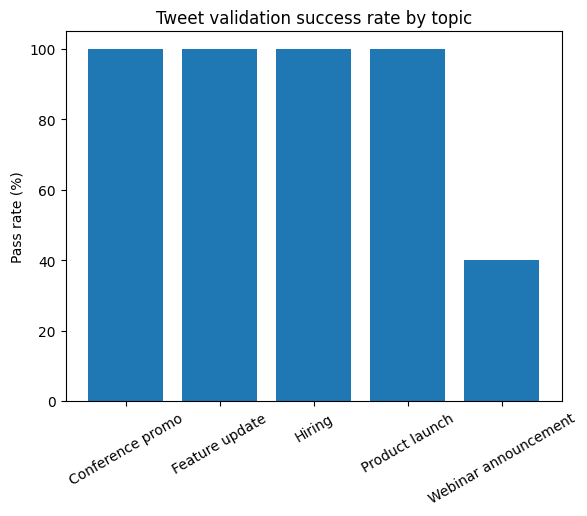

In [10]:
plt.figure()

plt.bar(report.index, report["pass_rate"])

plt.ylabel("Pass rate (%)")
plt.title("Tweet validation success rate by topic")
plt.xticks(rotation=30)

plt.show()

<Figure size 640x480 with 0 Axes>

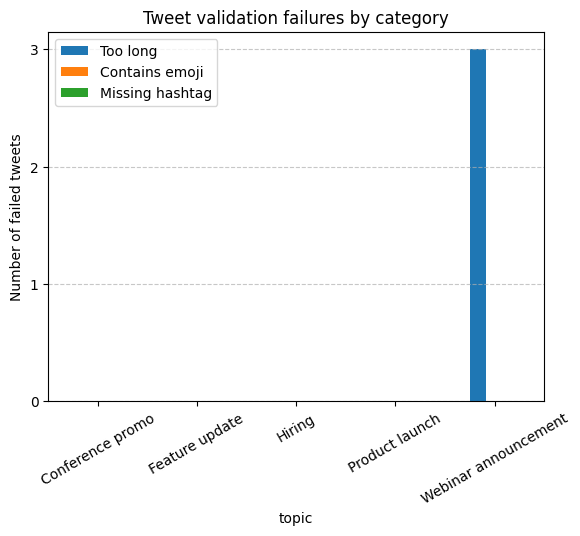

In [11]:
# Count failures per topic
failures = df.groupby("topic")[test_cols].apply(lambda x: (~x).sum())

failures = failures.rename(columns={
    "length_ok": "Too long",
    "no_emoji": "Contains emoji",
    "has_hashtag": "Missing hashtag"
})

plt.figure()

failures.plot(kind="bar", stacked=False)

plt.ylabel("Number of failed tweets")
plt.title("Tweet validation failures by category")
plt.xticks(rotation=30)
plt.yticks(np.arange(0, failures.values.max() + 1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## 5. Inspect the Failure Slice

The aggregate report shows that webinar announcements are the weak slice, and the detailed report shows why: they fail on length. Now we can inspect those rows directly.


In [12]:
webinar_failures = df.loc[
    (df["topic"] == "Webinar announcement") & (~df["length_ok"]),
    ["topic", "char_count", "tweet"]
]

webinar_failures


,topic,char_count,tweet
6,Webinar announcement,345,"Join our live webinar on practical LLM evaluation with Maya Chen, Senior AI Engineer, on October 12 at 10:00 UTC. We will cover length checks, tone constraints, hashtag rules, failure reports, and a step-by-step workflow your team can reuse after the session, plus a short Q&A on adapting this to real launch campaigns. #LLM #Evaluation #Webinar"
8,Webinar announcement,318,"Tomorrow's webinar brings together an engineer, a PM, and a developer advocate to walk through a tweet-generation example, show the validation code, discuss common failure patterns, and answer questions from teams shipping AI features across regulated, brand-sensitive, and high-volume workflows. #AI #Quality #Webinar"
10,Webinar announcement,303,"In next week's session, our team will show how to evaluate generated marketing copy across length, formatting, and brand constraints, then use the results to revise prompts for webinar posts, launch posts, and hiring updates, with a concrete before-and-after prompt rewrite. #MarketingAI #Evals #Webinar"


These rows suggest a plausible failure mode: webinar announcements often try to include the speaker, date, format, agenda, takeaways, and a registration call to action in one post. That is useful information, but it pushes the generated text over the character limit.

A next iteration might not be a generic prompt fix. We may need a webinar-specific instruction, for example: prioritize the topic, date, and registration call to action; omit speaker bios; keep the agenda to one short phrase.


## 6. A Bad Output Was Hiding in the Dataset

The aggregate checks helped us find the webinar length problem. But they also gave us a false sense of safety: one low-quality tweet was in the dataset from the beginning and passed every rule.

One simple way to spot this kind of issue is to inspect suspicious passing rows, for example the shortest outputs that passed all automated checks.


In [13]:
suspicious_passing_outputs = df.loc[
    df["passed_all"],
    ["topic", "char_count", "length_ok", "no_emoji", "has_hashtag", "passed_all", "tweet"]
].sort_values("char_count")

suspicious_passing_outputs.head(5)


,topic,char_count,length_ok,no_emoji,has_hashtag,passed_all,tweet
5,Product launch,12,True,True,True,True,Buy now. #AI
19,Feature update,91,True,True,True,True,New export flow: share concise eval summaries with reviewers before a release. #Quality #AI
24,Conference promo,94,True,True,True,True,We are sharing a practical checklist for debugging LLM outputs at the conference. #AI #Quality
23,Conference promo,95,True,True,True,True,Visit our booth for a hands-on look at eval templates for generated content. #Conference #Evals
13,Hiring,95,True,True,True,True,"Join our team to build tools that make AI products easier to test, debug, and ship. #Hiring #AI"


The first row passes because our tests only check length, emojis, and hashtag presence. They do not check whether the post is specific, persuasive, on-brand, useful, or non-spammy.

This is the core lesson: evaluators are imperfect, and tests encode only the quality criteria we remembered to write down. For broader judgment, we may need additional checks, human review, or an LLM-as-judge rubric that evaluates usefulness, specificity, brand fit, and call-to-action quality.
